# **DETERMINANTS AND DYNAMICS OF NIGERIA'S EXTERNAL RESERVES**

---



**DATA SOURCING AND CLEANING**

In [1]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import pandas_datareader.wb as wb

COUNTRY = 'NGA'
START_YEAR = 2005
END_YEAR = 2024

INDICATORS = {
    'FI.RES.TOTL.CD': 'reserves',
    'PA.NUS.FCRF': 'exchange_rate',
    'FR.INR.LEND': 'lending_rate',
    'BX.TRF.PWKR.CD.DT': 'remittances',
    'BX.KLT.DINV.CD.WD': 'fdi'  # Foreign Direct Investment
}

def fetch_panel():
    codes = list(INDICATORS.keys())
    raw = wb.download(indicator=codes, country=COUNTRY, start=START_YEAR, end=END_YEAR)

    raw = raw.reset_index().drop(columns=['country'])
    raw['year'] = raw['year'].astype(int)
    raw = raw.set_index('year').sort_index()
    raw = raw.rename(columns=INDICATORS)

    # Reorder columns to match variable names
    columns_names = list(INDICATORS.values())
    panel = raw[columns_names]

    # Drop columns that are completely empty (all NaN values)
    panel = panel.dropna(axis=1, how='all')

    # Use linear interpolation to fill gaps in columns that have SOME data
    panel = panel.interpolate(method='linear')

    # Fill edge cases (e.g., missing data at the very start or very end years)
    panel = panel.ffill().bfill()

    # CONVERT TO BILLIONS: convert columns with big currency values
    money_columns = ['reserves', 'remittances', 'fdi']

    for col in money_columns:
        if col in panel.columns:
            panel[col] = panel[col] / 1_000_000_000

    return panel

**CHARTS FOR ALL ECONOMIC VARIABLES**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

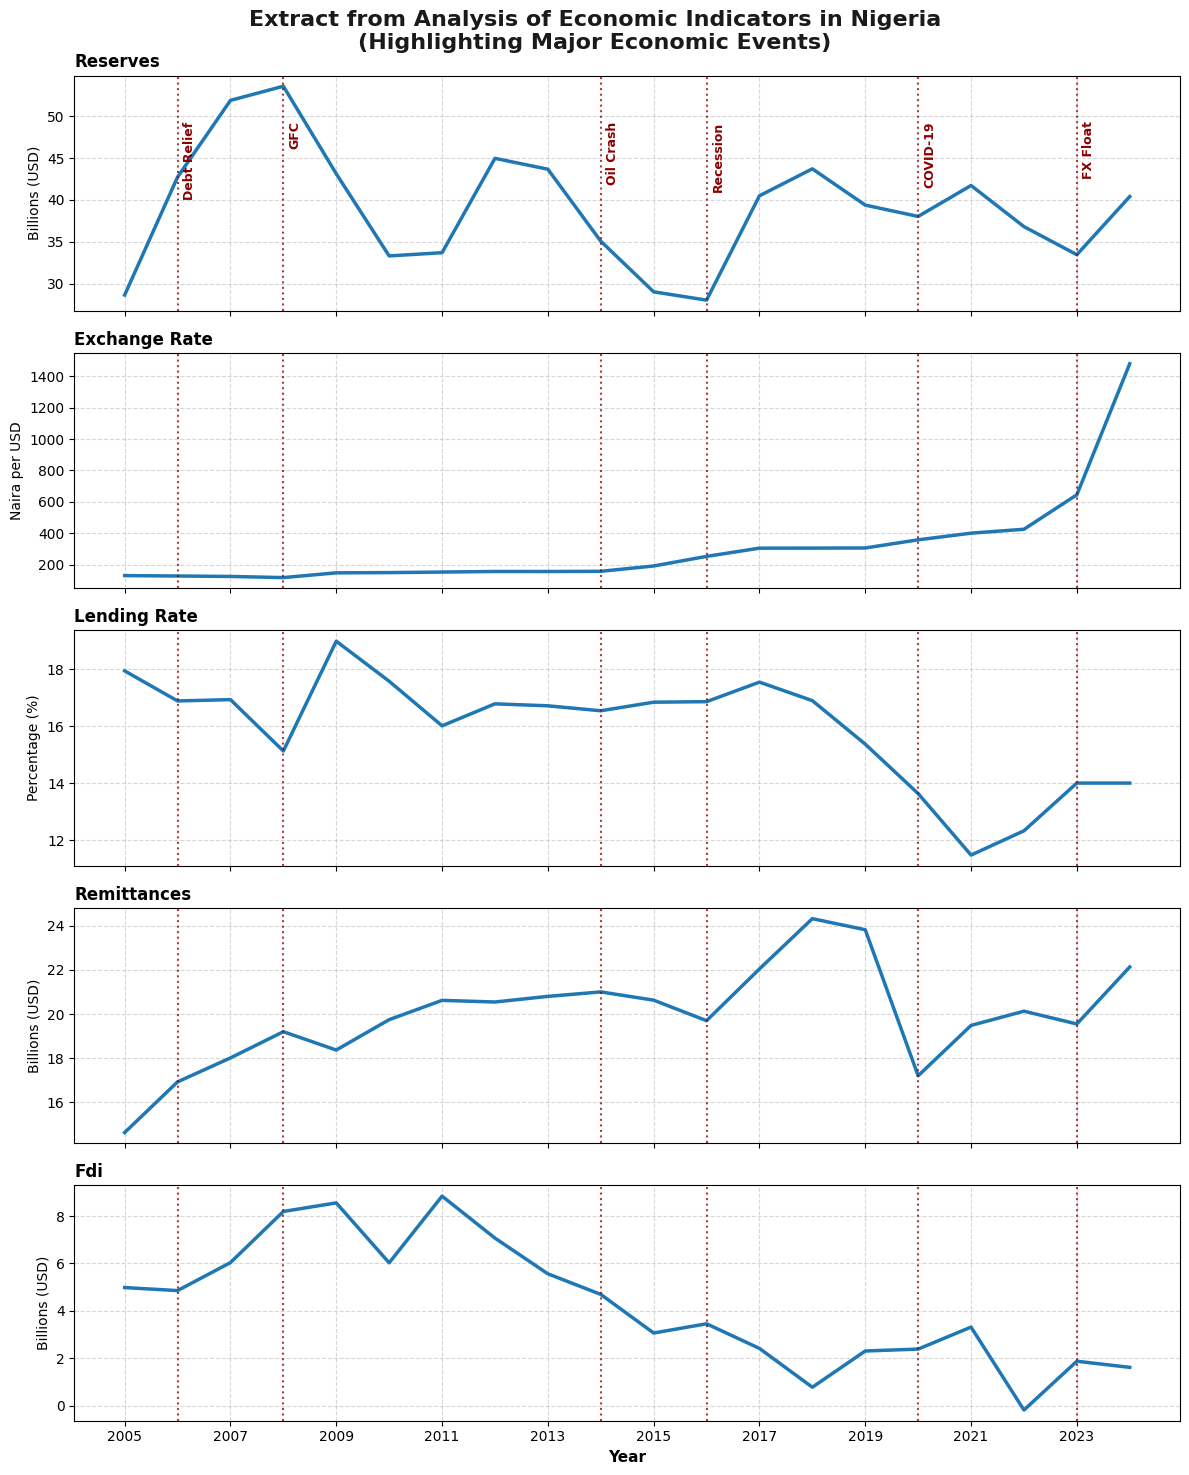

In [2]:
from google.colab import files
import matplotlib.pyplot as plt

data = fetch_panel()

# Define key historical events in Nigeria
EVENTS = {
    2006: ("Debt Relief", "Paris Club Debt Relief Agreement"),
    2008: ("GFC", "Global Financial Crisis Impact"),
    2014: ("Oil Crash", "Rebasing of GDP & Global Crude Price Collapse"),
    2016: ("Recession", "Naira Devaluation & Economic Recession"),
    2020: ("COVID-19", "Global Pandemic & Oil Price Collapse"),
    2023: ("FX Float", "Currency Float & Fuel Subsidy Removal")
}

# Create a separate subplot for each variable so they keep their unique scales
num_vars = len(data.columns)
fig, axes = plt.subplots(nrows=num_vars, ncols=1, figsize=(12, 3 * num_vars), sharex=True)

if num_vars == 1:
    axes = [axes]

plt.rcParams['axes.formatter.useoffset'] = False

fig.suptitle(
    "Extract from Analysis of Economic Indicators in Nigeria\n(Highlighting Major Economic Events)",
    fontsize=16,
    fontweight="bold",
    color="#1a1a1a",
    y=0.98,
)

for i, col in enumerate(data.columns):
    ax = axes[i]

    ax.plot(data.index, data[col], label=col.replace('_', ' ').title(), color='#1f77b4', linewidth=2.5)

    # Titles and clean up labels
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold', loc='left')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Label axes properly based on the variable units
    if col in ['reserves', 'remittances', 'fdi']:
        ax.set_ylabel("Billions (USD)")
    elif col == 'lending_rate':
        ax.set_ylabel("Percentage (%)")
    else:
        ax.set_ylabel("Naira per USD")

    # Add the historical event timeline vertical lines
    for year, (label, desc) in EVENTS.items():
        # Only draw line if the year falls within the data range
        if data.index.min() <= year <= data.index.max():
            ax.axvline(x=year, color='darkred', linestyle=':', linewidth=1.5, alpha=0.75)

            if i == 0:
                # Add text slightly shifted to the right of the line (+0.1)
                ax.text(year + 0.1, ax.get_ylim()[1] * 0.9, label,
                        color='darkred', rotation=90, verticalalignment='top',
                        fontsize=9, fontweight='bold')

plt.xlabel("Year", fontsize=11, fontweight='bold')
plt.xticks(range(int(data.index.min()), int(data.index.max()) + 1, 2))
plt.tight_layout()

# Save the plot as a single image file (like a PNG)
plt.savefig('Economic_Variables.png', bbox_inches='tight', dpi=300)

# Download the image file straight to your computer
files.download('Economic_Variables.png')

# Show the plot
plt.show()


**EXPLORATORY DATA ANALYSIS (EDA)**


EXPLORATORY DATA ANALYSIS: DESCRIPTIVE STATISTICS
               count    mean     std     min     25%     50%     75%      max  Skewness  Kurtosis
reserves        20.0   39.09    7.04   28.02   33.63   39.89   43.27    53.60      0.26     -0.18
exchange_rate   20.0  305.28  307.82  118.57  149.94  175.50  319.89  1478.97      3.24     11.90
lending_rate    20.0   15.93    1.94   11.48   14.85   16.76   16.91    18.99     -0.88      0.23
remittances     20.0   19.94    2.27   14.64   18.99   19.94   20.85    24.31     -0.22      0.73
fdi             20.0    4.29    2.62   -0.19    2.37    4.07    6.03     8.84      0.24     -0.83


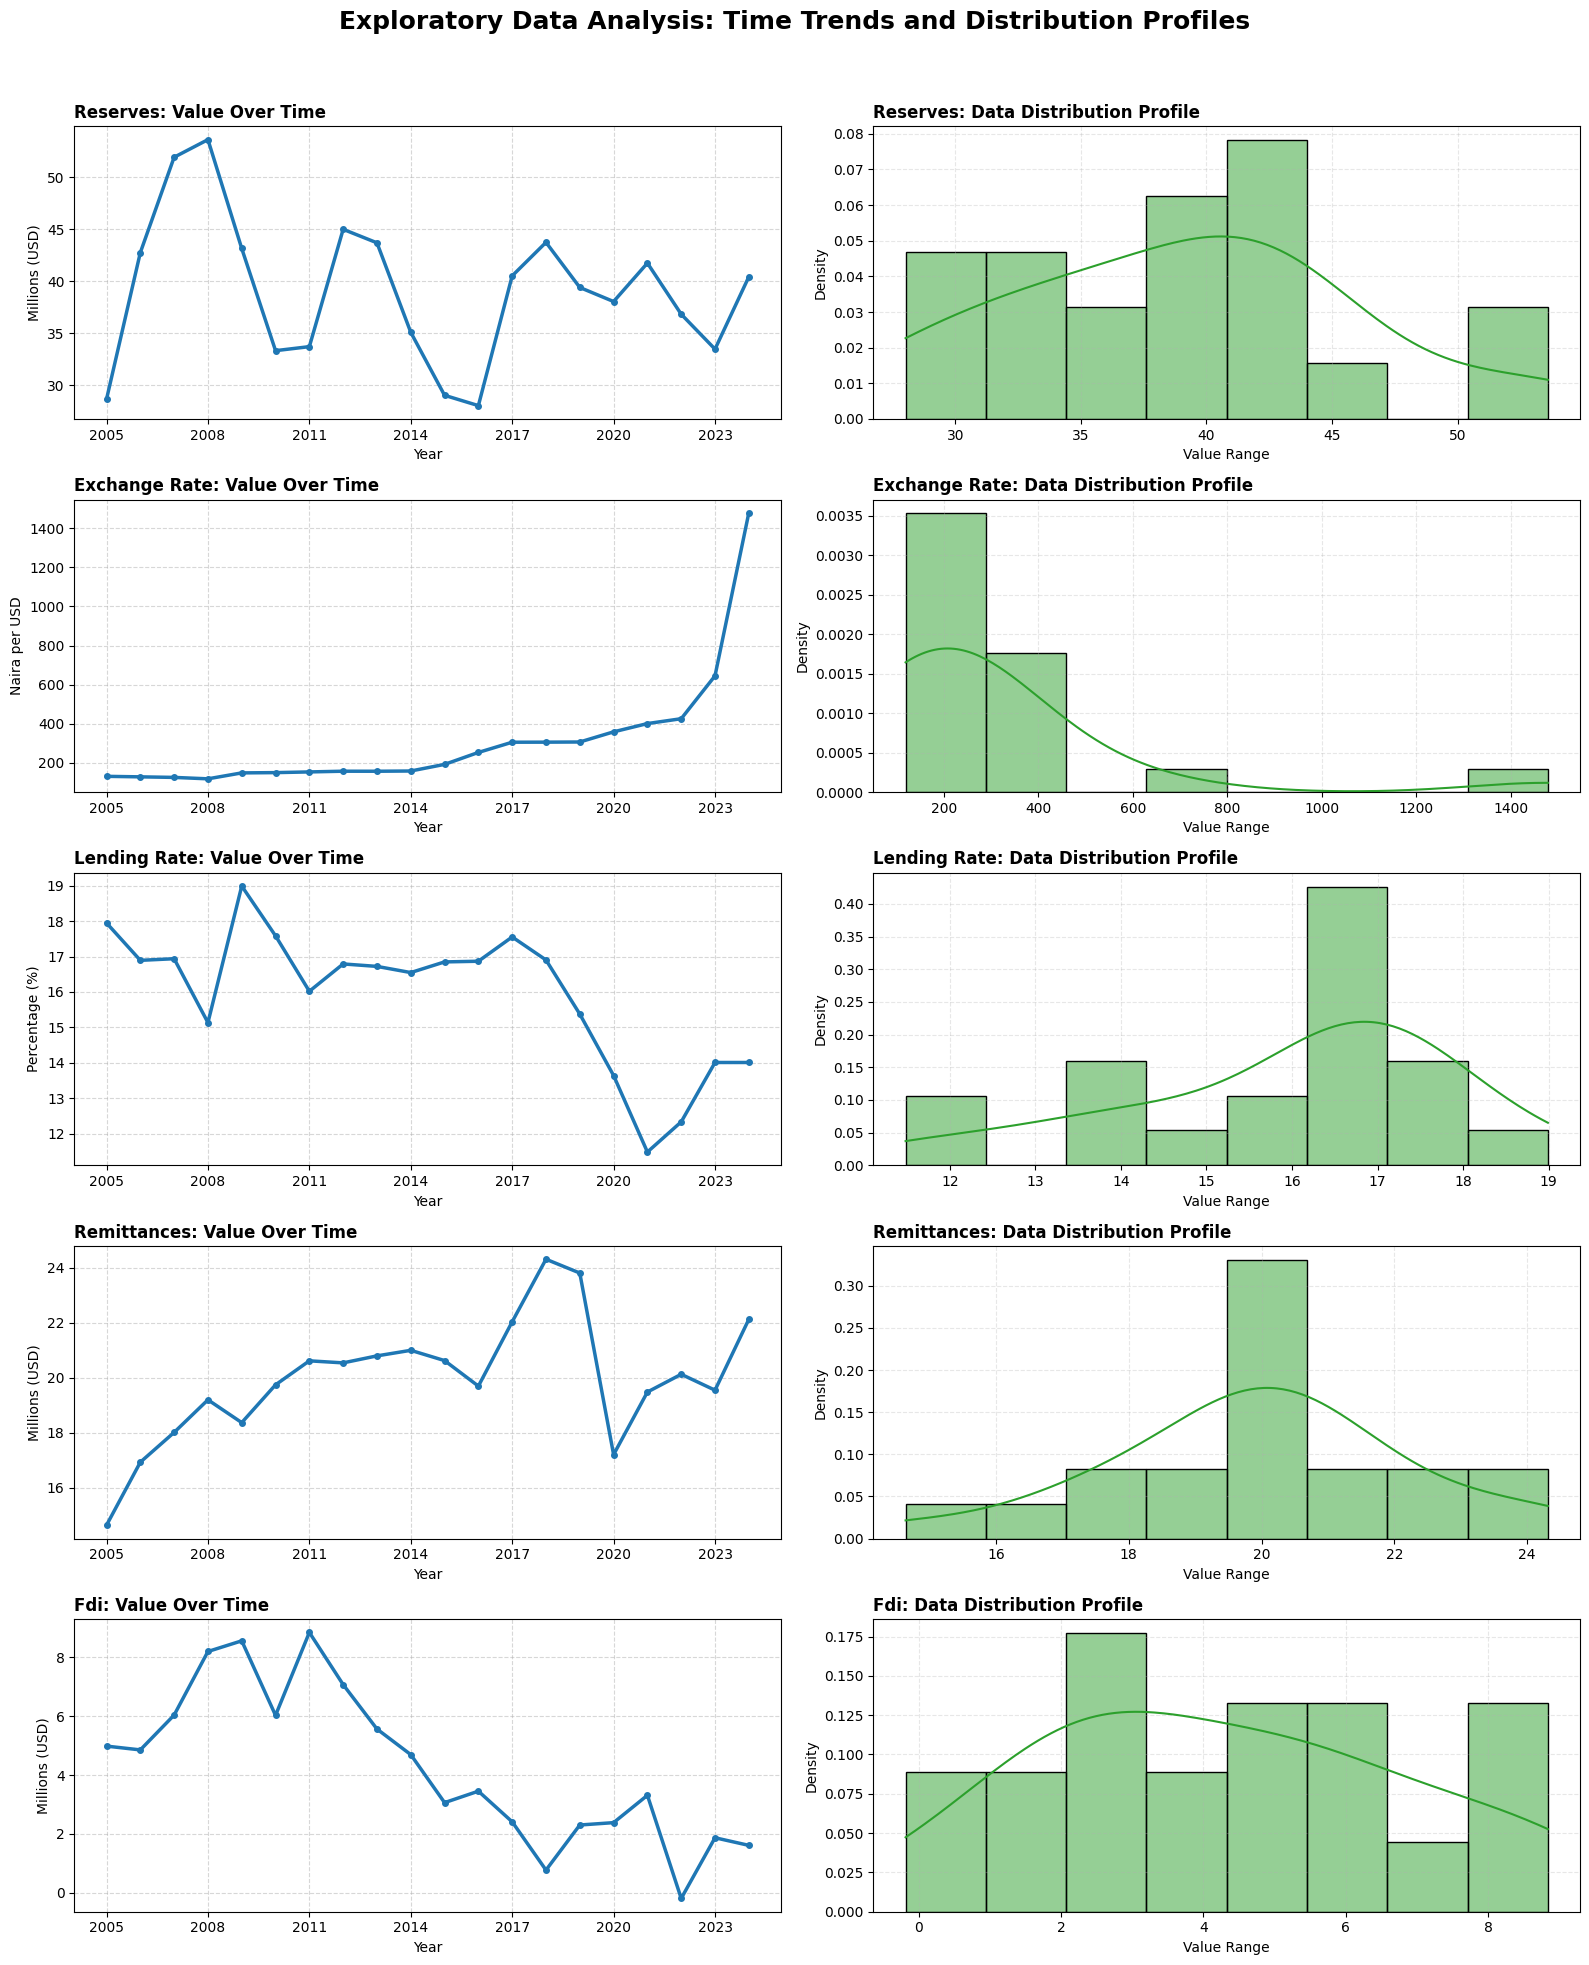

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Using the raw 'data' variable above
df_eda = data.copy()

print("=" * 90)
print("EXPLORATORY DATA ANALYSIS: DESCRIPTIVE STATISTICS")
print("=" * 90)
# Transpose places the variables as rows for clean report scannability
stats_summary = df_eda.describe().T
stats_summary['Skewness'] = df_eda.skew()
stats_summary['Kurtosis'] = df_eda.kurt()
print(stats_summary.round(2).to_string())
print("=" * 90)

# DUAL-DIAGNOSTIC GRAPH MATRIX
num_vars = len(df_eda.columns)
fig, axes = plt.subplots(nrows=num_vars, ncols=2, figsize=(16, 4 * num_vars))

fig.suptitle("Exploratory Data Analysis: Time Trends and Distribution Profiles",
             fontsize=18, fontweight='bold', y=0.98)

for i, col in enumerate(df_eda.columns):
    clean_name = col.replace('_', ' ').title()

    # ----------------------------------------------------
    # COLUMN 1: TIME TRENDS (Left Column)
    # ----------------------------------------------------
    ax_trend = axes[i, 0]
    ax_trend.plot(df_eda.index, df_eda[col], color='#1f77b4', linewidth=2.5, marker='o', markersize=4)
    ax_trend.set_title(f"{clean_name}: Value Over Time", fontsize=12, fontweight='bold', loc='left')
    ax_trend.grid(True, linestyle='--', alpha=0.5)

    # Label axes properly based on the variable units
    if col in ['reserves', 'remittances', 'fdi']:
        ax_trend.set_ylabel("Millions (USD)")
    elif col == 'lending_rate':
        ax_trend.set_ylabel("Percentage (%)")
    else:
        ax_trend.set_ylabel("Naira per USD")

    ax_trend.set_xlabel("Year")
    ax_trend.set_xticks(range(int(df_eda.index.min()), int(df_eda.index.max()) + 1, 3))

    # ----------------------------------------------------
    # COLUMN 2: DISTRIBUTION DENSITY (Right Column)
    # ----------------------------------------------------
    ax_dist = axes[i, 1]

    sns.histplot(df_eda[col], kde=True, color='#2ca02c', ax=ax_dist, bins=8, stat="density")
    ax_dist.set_title(f"{clean_name}: Data Distribution Profile", fontsize=12, fontweight='bold', loc='left')
    ax_dist.grid(True, linestyle='--', alpha=0.3)
    ax_dist.set_xlabel("Value Range")
    ax_dist.set_ylabel("Density")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**UNIT ROOT TESTS**

In [4]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 10.8 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
from arch.unitroot import ADF, KPSS

row_list = []

# Define the trends we want to evaluate (KPSS does not support trend="n" (no constant), so we only use "c" and "ct" for it)
TREND_TYPES = ["n", "c", "ct"]

for col in data.columns:
    clean_name = col.replace('_', ' ').title()

    for trend in TREND_TYPES:
        # Run ADF Test
        adf_result = ADF(data[col], trend=trend, method="bic")
        adf_stat = adf_result.stat
        adf_p = adf_result.pvalue

        if trend in ["c", "ct"]:
            kpss_result = KPSS(data[col], trend=trend, lags=-1)
            kpss_stat = kpss_result.stat
            kpss_p = kpss_result.pvalue
        else:
            # Leave blank for trend="n" since KPSS doesn't support it
            kpss_stat = float('nan')
            kpss_p = float('nan')

        # Evaluate Unit Root Status based on the p-values
        # ADF: p > 0.05 means Unit Root exists
        # KPSS: p < 0.05 means Unit Root exists
        if trend == "n":
            conclusion = "Has Unit Root. Needs differencing!" if adf_p > 0.05 else "Stationary! Safe to use in model."
        else:
            if adf_p > 0.05 and kpss_p < 0.05:
                conclusion = "Has Unit Root (Strong). Needs differencing!"
            elif adf_p > 0.05 or kpss_p < 0.05:
                conclusion = "Has Unit Root (Mixed). Needs differencing!"
            else:
                conclusion = "Stationary! Safe to use in model."

        # Append row results
        row_list.append({
            "Variable": clean_name,
            "Trend Model": trend.upper(),
            "ADF Stat": round(adf_stat, 4),
            "ADF p-val": round(adf_p, 4),
            "KPSS Stat": round(kpss_stat, 4) if not pd.isna(kpss_stat) else "-",
            "KPSS p-val": round(kpss_p, 4) if not pd.isna(kpss_p) else "-",
            "Status": conclusion
        })

multi_trend_table = pd.DataFrame(row_list)
multi_trend_table = multi_trend_table.set_index(["Variable", "Trend Model"])

print("=" * 100)
print("MULTI-TREND UNIT ROOT SPECIFICATION TABLE")
print("=" * 100)
print(multi_trend_table.to_string())
print("=" * 100)

MULTI-TREND UNIT ROOT SPECIFICATION TABLE
                           ADF Stat  ADF p-val KPSS Stat KPSS p-val                                       Status
Variable      Trend Model                                                                                       
Reserves      N             -0.3019     0.5753         -          -           Has Unit Root. Needs differencing!
              C             -5.0745     0.0000    0.2789     0.1555            Stationary! Safe to use in model.
              CT            -5.1789     0.0001    0.2443     0.0055   Has Unit Root (Mixed). Needs differencing!
Exchange Rate N             -0.5610     0.4709         -          -           Has Unit Root. Needs differencing!
              C              1.7566     0.9983    0.3785     0.0825   Has Unit Root (Mixed). Needs differencing!
              CT             3.1997     1.0000    0.1782     0.0246  Has Unit Root (Strong). Needs differencing!
Lending Rate  N             -0.7626     0.3862        

**CHARTS FOR TRANSFORMED DATA**

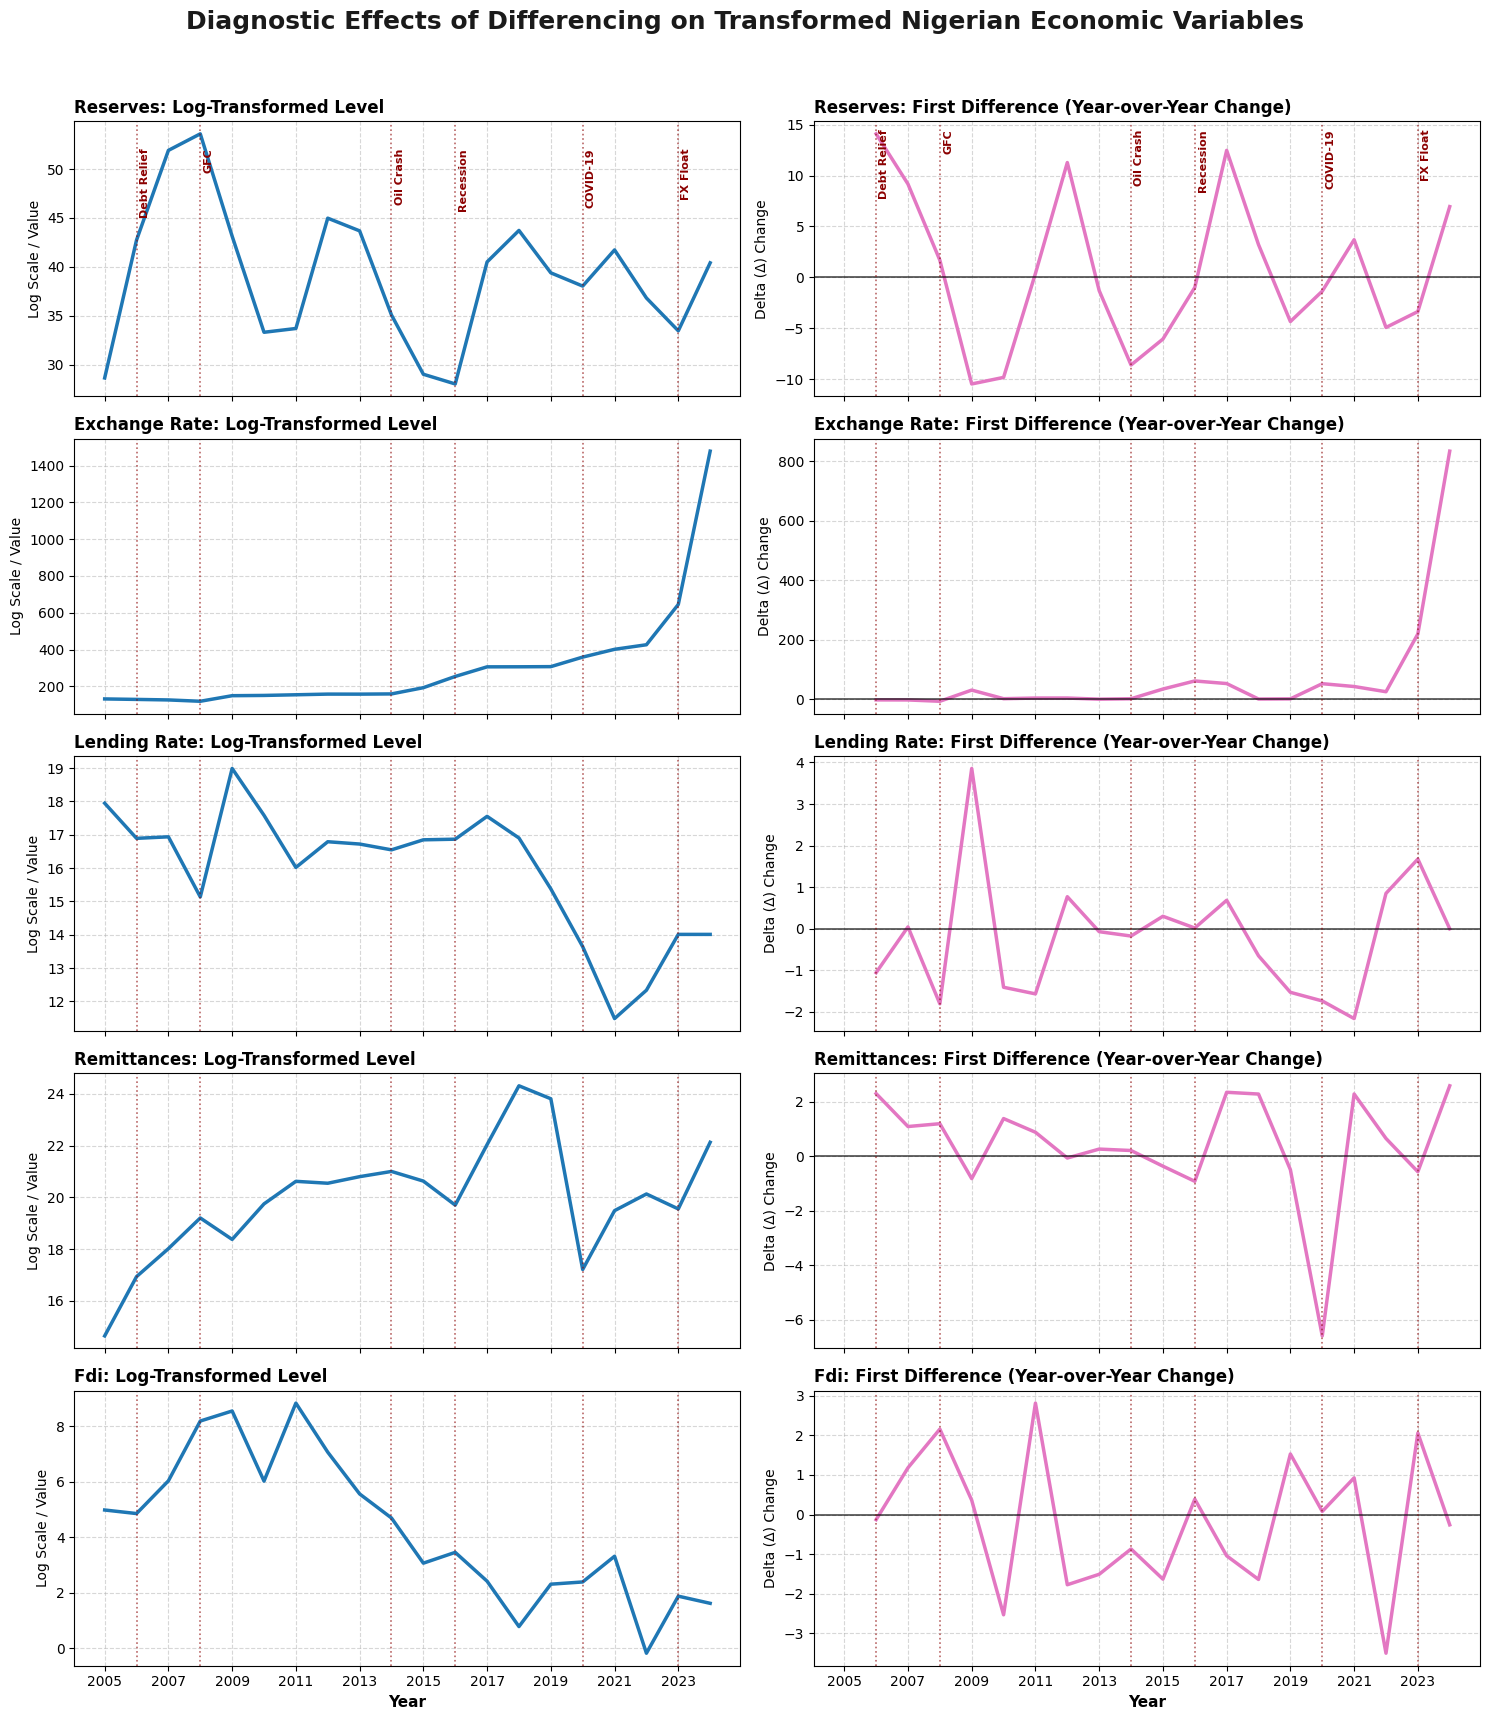

In [6]:
import matplotlib.pyplot as plt

data_transformed = data.copy()
data_differenced = data_transformed.diff().dropna()

num_vars = len(data_transformed.columns)
fig, axes = plt.subplots(nrows=num_vars, ncols=2, figsize=(15, 3.5 * num_vars), sharex=True)

# Define our historical timeline events for Nigeria to map onto the charts
EVENTS = {
    2006: "Debt Relief",
    2008: "GFC",
    2014: "Oil Crash",
    2016: "Recession",
    2020: "COVID-19",
    2023: "FX Float"
}

fig.suptitle("Diagnostic Effects of Differencing on Transformed Nigerian Economic Variables",
             fontsize=18, fontweight='bold', color='#1a1a1a', y=0.98)

for i, col in enumerate(data_transformed.columns):
    clean_name = col.replace('_', ' ').title()

    # ----------------------------------------------------
    # COLUMN 1: LOG-TRANSFORMED LEVELS (Left Side)
    # ----------------------------------------------------
    ax_left = axes[i, 0]
    ax_left.plot(data_transformed.index, data_transformed[col], color='#1f77b4', linewidth=2.5, label='Log Level')
    ax_left.set_title(f"{clean_name}: Log-Transformed Level", fontsize=12, fontweight='bold', loc='left')
    ax_left.grid(True, linestyle='--', alpha=0.5)
    ax_left.set_ylabel("Log Scale / Value")

    # Draw event reference lines on the left side
    for year, label in EVENTS.items():
        if data_transformed.index.min() <= year <= data_transformed.index.max():
            ax_left.axvline(x=year, color='darkred', linestyle=':', linewidth=1.2, alpha=0.6)
            if i == 0: # Place labels only on the top chart to avoid overcrowding
                ax_left.text(year + 0.1, ax_left.get_ylim()[1] * 0.95, label,
                             color='darkred', rotation=90, verticalalignment='top', fontsize=8, fontweight='bold')

    # ----------------------------------------------------
    # COLUMN 2: FIRST DIFFERENCE (Right Side)
    # ----------------------------------------------------
    ax_right = axes[i, 1]
    # Dropna() handles the very first year (2005) which becomes blank during differencing
    ax_right.plot(data_differenced.index, data_differenced[col], color='#e377c2', linewidth=2.5, label='1st Difference')
    ax_right.set_title(f"{clean_name}: First Difference (Year-over-Year Change)", fontsize=12, fontweight='bold', loc='left')
    ax_right.grid(True, linestyle='--', alpha=0.5)
    ax_right.set_ylabel("Delta (Δ) Change")

    # Draw a bold horizontal guide line at zero to visually check for stationarity
    ax_right.axhline(y=0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)

    # Draw event reference lines on the right side
    for year, label in EVENTS.items():
        if data_transformed.index.min() <= year <= data_transformed.index.max():
            ax_right.axvline(x=year, color='darkred', linestyle=':', linewidth=1.2, alpha=0.6)
            if i == 0:
                ax_right.text(year + 0.1, ax_right.get_ylim()[1] * 0.95, label,
                             color='darkred', rotation=90, verticalalignment='top', fontsize=8, fontweight='bold')

for ax in axes[-1, :]:
    ax.set_xlabel("Year", fontsize=11, fontweight='bold')
    ax.set_xticks(range(int(data_transformed.index.min()), int(data_transformed.index.max()) + 1, 2))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**UNIT ROOT TEST FOR DIFFERENCE OF TRANSFORMED DATA**

In [7]:
import numpy as np
import pandas as pd
from arch.unitroot import ADF, KPSS

# UNIT ROOT MATRIX
row_list = []
TREND_TYPES = ["n", "c", "ct"]

for col in data_differenced.columns:
    clean_name = col.replace('_', ' ').title()

    for trend in TREND_TYPES:
        # Run ADF Test
        adf_result = ADF(data_differenced[col], trend=trend, method="bic")
        adf_stat = adf_result.stat
        adf_p = adf_result.pvalue

        # Run KPSS Test (skip trend="n")
        if trend in ["c", "ct"]:
            kpss_result = KPSS(data_differenced[col], trend=trend, lags=-1)
            kpss_stat = kpss_result.stat
            kpss_p = kpss_result.pvalue
        else:
            kpss_stat = float('nan')
            kpss_p = float('nan')

        # Evaluate Status based on p-values
        if trend == "n":
            conclusion = "Has Unit Root." if adf_p > 0.05 else "Stationary! Safe to use in model."
        else:
            if adf_p > 0.05 and kpss_p < 0.05:
                conclusion = "Has Unit Root (Strong)."
            elif adf_p > 0.05 or kpss_p < 0.05:
                conclusion = "Has Unit Root (Mixed)."
            else:
                conclusion = "Stationary! Safe to use in model."

        # Append structured row results
        row_list.append({
            "Variable": clean_name,
            "Trend Model": trend.upper(),
            "ADF Stat": round(adf_stat, 4),
            "ADF p-val": round(adf_p, 4),
            "KPSS Stat": round(kpss_stat, 4) if not pd.isna(kpss_stat) else "-",
            "KPSS p-val": round(kpss_p, 4) if not pd.isna(kpss_p) else "-",
            "Status": conclusion
        })

multi_trend_table = pd.DataFrame(row_list)
multi_trend_table = multi_trend_table.set_index(["Variable", "Trend Model"])

print("=" * 110)
print("MULTI-TREND UNIT ROOT SPECIFICATION TABLE FOR TRANSFORMED DATA")
print("=" * 110)
print(multi_trend_table.to_string())
print("=" * 110)

MULTI-TREND UNIT ROOT SPECIFICATION TABLE FOR TRANSFORMED DATA
                           ADF Stat  ADF p-val KPSS Stat KPSS p-val                             Status
Variable      Trend Model                                                                             
Reserves      N             -5.8060     0.0000         -          -  Stationary! Safe to use in model.
              C             -5.6126     0.0000    0.2314     0.2144  Stationary! Safe to use in model.
              CT            -5.3448     0.0000    0.1879     0.0197             Has Unit Root (Mixed).
Exchange Rate N              1.3969     0.9591         -          -                     Has Unit Root.
              C              1.7011     0.9981    0.3752     0.0842             Has Unit Root (Mixed).
              CT             1.9747     1.0000    0.1807     0.0233            Has Unit Root (Strong).
Lending Rate  N             -4.7705     0.0000         -          -  Stationary! Safe to use in model.
          

**COINTEGRATION TEST**

In [8]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
# ----------------------------------------------------------
# Johansen Cointegration Test
# ----------------------------------------------------------

johansen_df = data_transformed.copy()

# 2. Run the Johansen test
# det_order=0 means I include a constant intercept
# k_ar_diff=1 means I use 1 time lag for differences
res = coint_johansen(johansen_df, det_order=0, k_ar_diff=1)

print("=" * 65)
print("JOHANSEN MULTIVARIATE COINTEGRATION TEST")
print("=" * 65)
print(f"{'Variable Count':<18}{'Trace Statistic':<18}{'5% Critical Value':<18}")
print("-" * 65)

for i in range(len(res.lr1)):
    # lr1 contains the trace statistics
    # cvm[:, 1] contains the 5% critical values
    print(f"r <= {i:<14}{res.lr1[i]:<18.4f}{res.cvm[i, 1]:<18.4f}")
print("=" * 65)

JOHANSEN MULTIVARIATE COINTEGRATION TEST
Variable Count    Trace Statistic   5% Critical Value 
-----------------------------------------------------------------
r <= 0             116.2296          33.8777           
r <= 1             48.4015           27.5858           
r <= 2             21.7480           21.1314           
r <= 3             5.4340            14.2639           
r <= 4             0.2910            3.8415            


**VECTOR ERROR CORRECTION MODEL (VECM)**

In [9]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import VECM

# VECM needs the non-stationary log levels because it handles the differencing internally
vemc_df = data_transformed.copy()

# Fit the VECM
# k_ar_diff=1: Uses 1 time lag for the short-term differences
# coint_rank=3: Tells the model that your Johansen test discovered exactly 3 relationships
# deterministic='co': Includes a constant baseline intercept in the long-term equations
vecm_model = VECM(vemc_df, k_ar_diff=1, coint_rank=3, deterministic='co')
vecm_results = vecm_model.fit()

print("=" * 80)
print("FINAL VECTOR ERROR CORRECTION MODEL (VECM) SUMMARY")
print("=" * 80)
print(vecm_results.summary())
print("=" * 80)

FINAL VECTOR ERROR CORRECTION MODEL (VECM) SUMMARY
Det. terms outside the coint. relation & lagged endog. parameters for equation reserves
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               10.3942      8.845      1.175      0.240      -6.941      27.729
L1.reserves          0.6506      0.097      6.717      0.000       0.461       0.840
L1.exchange_rate    -0.0929      0.023     -4.107      0.000      -0.137      -0.049
L1.lending_rate     -1.0281      0.541     -1.901      0.057      -2.088       0.032
L1.remittances      -0.1542      0.308     -0.500      0.617      -0.758       0.450
L1.fdi               1.2822      0.401      3.197      0.001       0.496       2.068
Det. terms outside the coint. relation & lagged endog. parameters for equation exchange_rate
                       coef    std err          z      P>|z|      [0.025      0.975]
---

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


In [10]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# ==========================================
# PRE & POST EXCHANGE RATE FLOAT TIMELINE SPLIT
# ==========================================

# Split the cleaned log levels data
pre_float = data_transformed.loc[data_transformed.index <= 2022]
post_float = data_transformed.loc[data_transformed.index >= 2023]

print("=" * 60)
print("PRE vs POST FX FLOAT: LOG-LEVEL MEAN COMPARISONS")
print("=" * 60)
for col in data_transformed.columns:
    clean_name = col.replace('_', ' ').title()
    mean_pre = pre_float[col].mean()
    mean_post = post_float[col].mean()
    print(f"{clean_name:<20} | Pre-Float Mean: {mean_pre:.4f} | Post-Float Mean: {mean_post:.4f}")
print("=" * 60)

# ==========================================
# SYSTEM STATISTICAL DIAGNOSTIC TESTS (CORRECTED)
# ==========================================
print("\n" + "=" * 60)
print("STATISTICAL SPECIFICATION CHECKS (VECM SYSTEM)")
print("=" * 60)

# Jarque-Bera Normality Test
normality_test = vecm_results.test_normality()
print("Normality Check (Jarque-Bera):")
# FIXED: Changed .statistic to .test_statistic
print(f" -> Test Statistic: {normality_test.test_statistic:.4f}")
print(f" -> System p-value:  {normality_test.pvalue:.4f}")

if normality_test.pvalue > 0.05:
    print(" -> Verdict: The model's errors are normally distributed.")
else:
    print(" -> Verdict: Warnings. Extreme macro shock years cause distribution skew.")

PRE vs POST FX FLOAT: LOG-LEVEL MEAN COMPARISONS
Reserves             | Pre-Float Mean: 39.3286 | Post-Float Mean: 36.9292
Exchange Rate        | Pre-Float Mean: 221.1875 | Post-Float Mean: 1062.0796
Lending Rate         | Pre-Float Mean: 16.1436 | Post-Float Mean: 14.0106
Remittances          | Pre-Float Mean: 19.8421 | Post-Float Mean: 20.8382
Fdi                  | Pre-Float Mean: 4.5744 | Post-Float Mean: 1.7433

STATISTICAL SPECIFICATION CHECKS (VECM SYSTEM)
Normality Check (Jarque-Bera):
 -> Test Statistic: 3.9309
 -> System p-value:  0.9504
 -> Verdict: The model's errors are normally distributed.


**ISOLATION OF THE STRUCTURAL BREAK**

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import VECM

vemc_df = data_transformed.copy()

# Construct the Structural Policy Switch (Dummy Variable) ---
# Create a new column filled with zeros matching the dataset index years
policy_dummy = pd.DataFrame(0, index=vemc_df.index, columns=['FX_Float_2023'])

# Flip the switch to 1 for the year 2023 and all years after it
policy_dummy.loc[policy_dummy.index >= 2023, 'FX_Float_2023'] = 1

print("--- Structural Dummy Alignment Check ---")
print(policy_dummy.tail(4)) # Quick visual print to see if it works
print("=" * 60)

# Fit the VECM with the Exogenous Switch
# exog=policy_dummy: Passes our structural switch to isolate the 2023 break
vecm_model_dummy = VECM(vemc_df, k_ar_diff=1, coint_rank=3,
                        exog=policy_dummy, deterministic='co')
vecm_dummy_results = vecm_model_dummy.fit()

print("=" * 80)
print("VECM SUMMARY MATRIX WITH STRUCTURAL BREAK EXOGENOUS ISOLATION")
print("=" * 80)
print(vecm_dummy_results.summary())
print("=" * 80)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


--- Structural Dummy Alignment Check ---
      FX_Float_2023
year               
2021              0
2022              0
2023              1
2024              1
VECM SUMMARY MATRIX WITH STRUCTURAL BREAK EXOGENOUS ISOLATION
Det. terms outside the coint. relation & lagged endog. parameters for equation reserves
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.7201      4.216     -0.408      0.683      -9.982       6.542
exog1               12.8035      1.670      7.665      0.000       9.530      16.077
L1.reserves          0.7241      0.051     14.196      0.000       0.624       0.824
L1.exchange_rate    -0.0997      0.019     -5.150      0.000      -0.138      -0.062
L1.lending_rate     -1.8471      0.314     -5.881      0.000      -2.463      -1.232
L1.remittances      -0.6211      0.161     -3.868      0.000      -0.936      -0.306
L1.fdi   

**VECM DIAGNOSTICS PANEL**

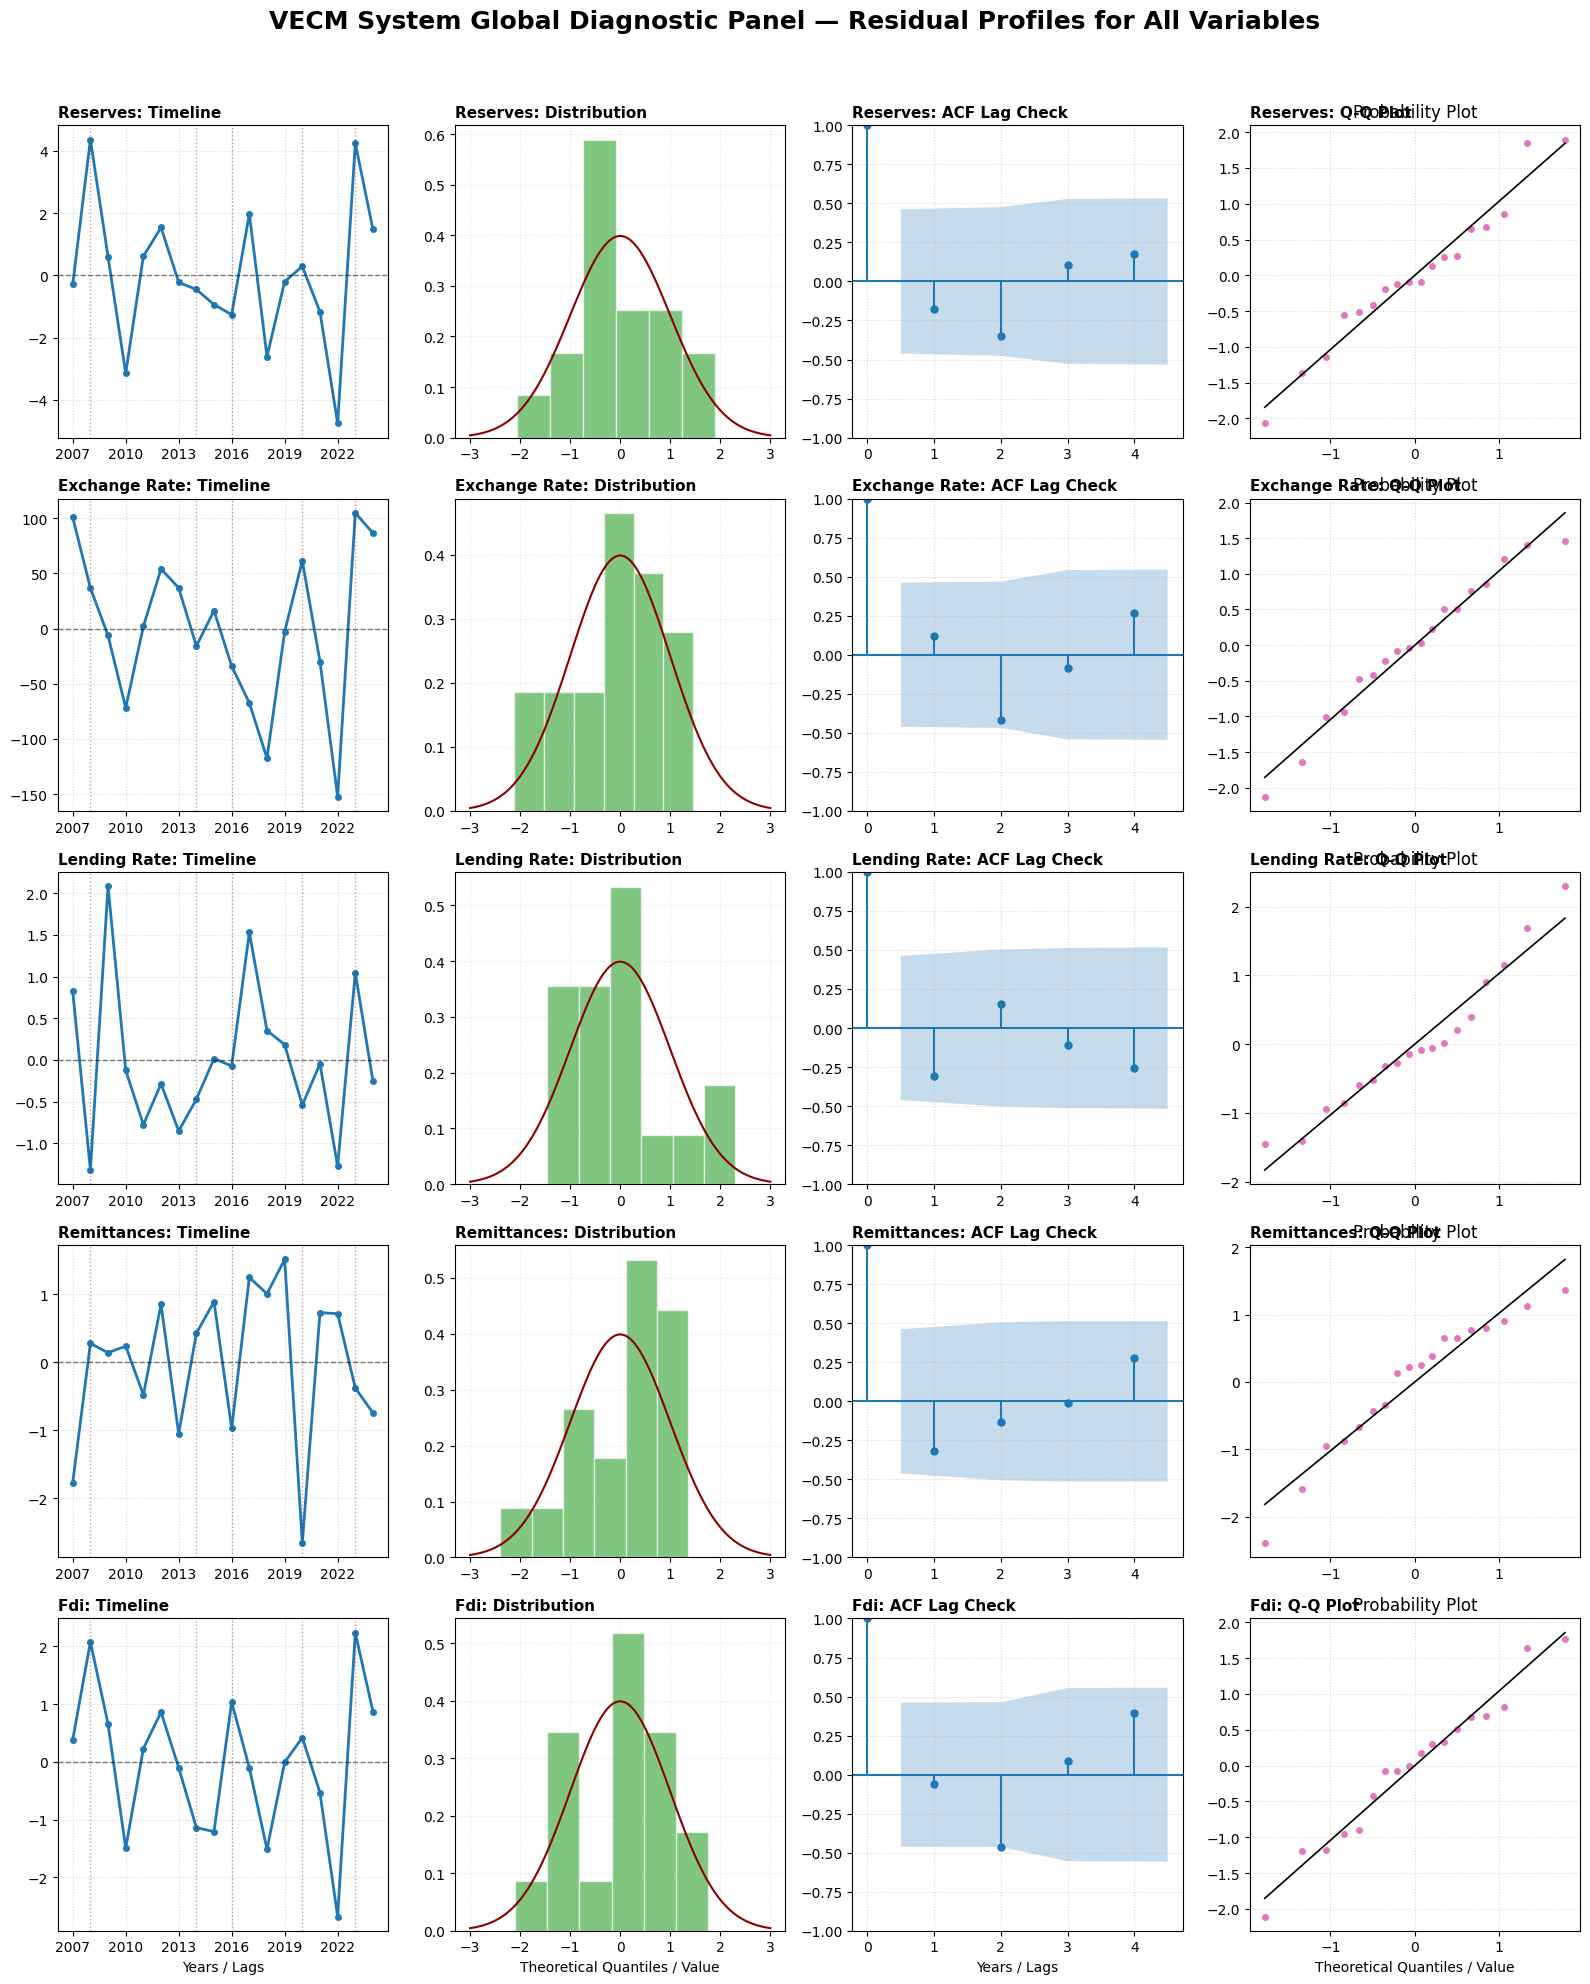

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

var_names = list(data_transformed.columns)
num_vars = len(var_names)

# Re-align the VECM residuals timeline with the proper calendar years
resid_years = data_transformed.index[-len(vecm_results.resid):]

fig, axes = plt.subplots(nrows=num_vars, ncols=4, figsize=(16, 4 * num_vars))

fig.suptitle("VECM System Global Diagnostic Panel — Residual Profiles for All Variables",
             fontsize=18, fontweight='bold', y=0.99)

# Define Nigeria's major milestone years for vertical marker references
EVENTS = [2006, 2008, 2014, 2016, 2020, 2023]

# Loop Through Every Variable to Populate the Grid ---
for idx, col in enumerate(var_names):
    clean_name = col.replace('_', ' ').title()

    # Extract the specific error series for this variable's equation
    col_resid = pd.Series(vecm_results.resid[:, idx], index=resid_years)

    # Standardize the data to center the distribution tests around 0
    standardized_resid = (col_resid - col_resid.mean()) / col_resid.std()

    # Isolate the specific 4 axes boxes for this current row
    ax_time  = axes[idx, 0]
    ax_hist  = axes[idx, 1]
    ax_acf   = axes[idx, 2]
    ax_qq    = axes[idx, 3]

    # ----------------------------------------------------
    # PLOT A: RESIDUAL TIMELINE (Column 1)
    # ----------------------------------------------------
    ax_time.plot(col_resid.index, col_resid.values, color='#1f77b4', linewidth=2, marker='o', markersize=4)
    ax_time.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax_time.set_title(f"{clean_name}: Timeline", fontsize=11, fontweight='bold', loc='left')
    ax_time.grid(True, linestyle=':', alpha=0.5)
    ax_time.set_xticks(range(int(col_resid.index.min()), int(col_resid.index.max()) + 1, 3))

    # Add vertical economic events indicators
    for yr in EVENTS:
        if col_resid.index.min() <= yr <= col_resid.index.max():
            ax_time.axvline(x=yr, color='darkred', linestyle=':', linewidth=1, alpha=0.4)

    # ----------------------------------------------------
    # PLOT B: DISTRIBUTION HISTOGRAM (Column 2)
    # ----------------------------------------------------
    ax_hist.hist(standardized_resid, bins=6, density=True, color='#2ca02c', alpha=0.6, edgecolor='white')
    # Overlay a baseline bell curve for clear symmetry reference checks
    x_ref = np.linspace(-3, 3, 100)
    ax_hist.plot(x_ref, stats.norm.pdf(x_ref, 0, 1), color='darkred', linewidth=1.5, linestyle='-')
    ax_hist.set_title(f"{clean_name}: Distribution", fontsize=11, fontweight='bold', loc='left')
    ax_hist.grid(True, linestyle=':', alpha=0.3)

    # ----------------------------------------------------
    # PLOT C: AUTOCORRELATION FUNCTION / ACF (Column 3)
    # ----------------------------------------------------
    # Set lags=4 to account for the limited number of rows in our annual dataset
    plot_acf(col_resid, ax=ax_acf, lags=4, alpha=0.05, title="")
    ax_acf.set_title(f"{clean_name}: ACF Lag Check", fontsize=11, fontweight='bold', loc='left')
    ax_acf.grid(True, linestyle=':', alpha=0.5)

    # ----------------------------------------------------
    # PLOT D: NORMAL Q-Q SPECIFICATION (Column 4)
    # ----------------------------------------------------
    stats.probplot(standardized_resid, dist="norm", plot=ax_qq)
    # Style the dots and trend lines cleanly
    ax_qq.get_lines()[0].set_markerfacecolor('#e377c2')
    ax_qq.get_lines()[0].set_markeredgecolor('#e377c2')
    ax_qq.get_lines()[0].set_markersize(4)
    ax_qq.get_lines()[1].set_color('black')
    ax_qq.get_lines()[1].set_linewidth(1.2)
    ax_qq.set_title(f"{clean_name}: Q-Q Plot", fontsize=11, fontweight='bold', loc='left')
    ax_qq.set_xlabel("")
    ax_qq.set_ylabel("")
    ax_qq.grid(True, linestyle=':', alpha=0.5)

# Add shared axis instructions to bottom rows
for ax in axes[-1, :]:
    if ax in [axes[-1, 0], axes[-1, 2]]:
        ax.set_xlabel("Years / Lags")
    else:
        ax.set_xlabel("Theoretical Quantiles / Value")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


**Impulse Response Functions (IRFs)**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

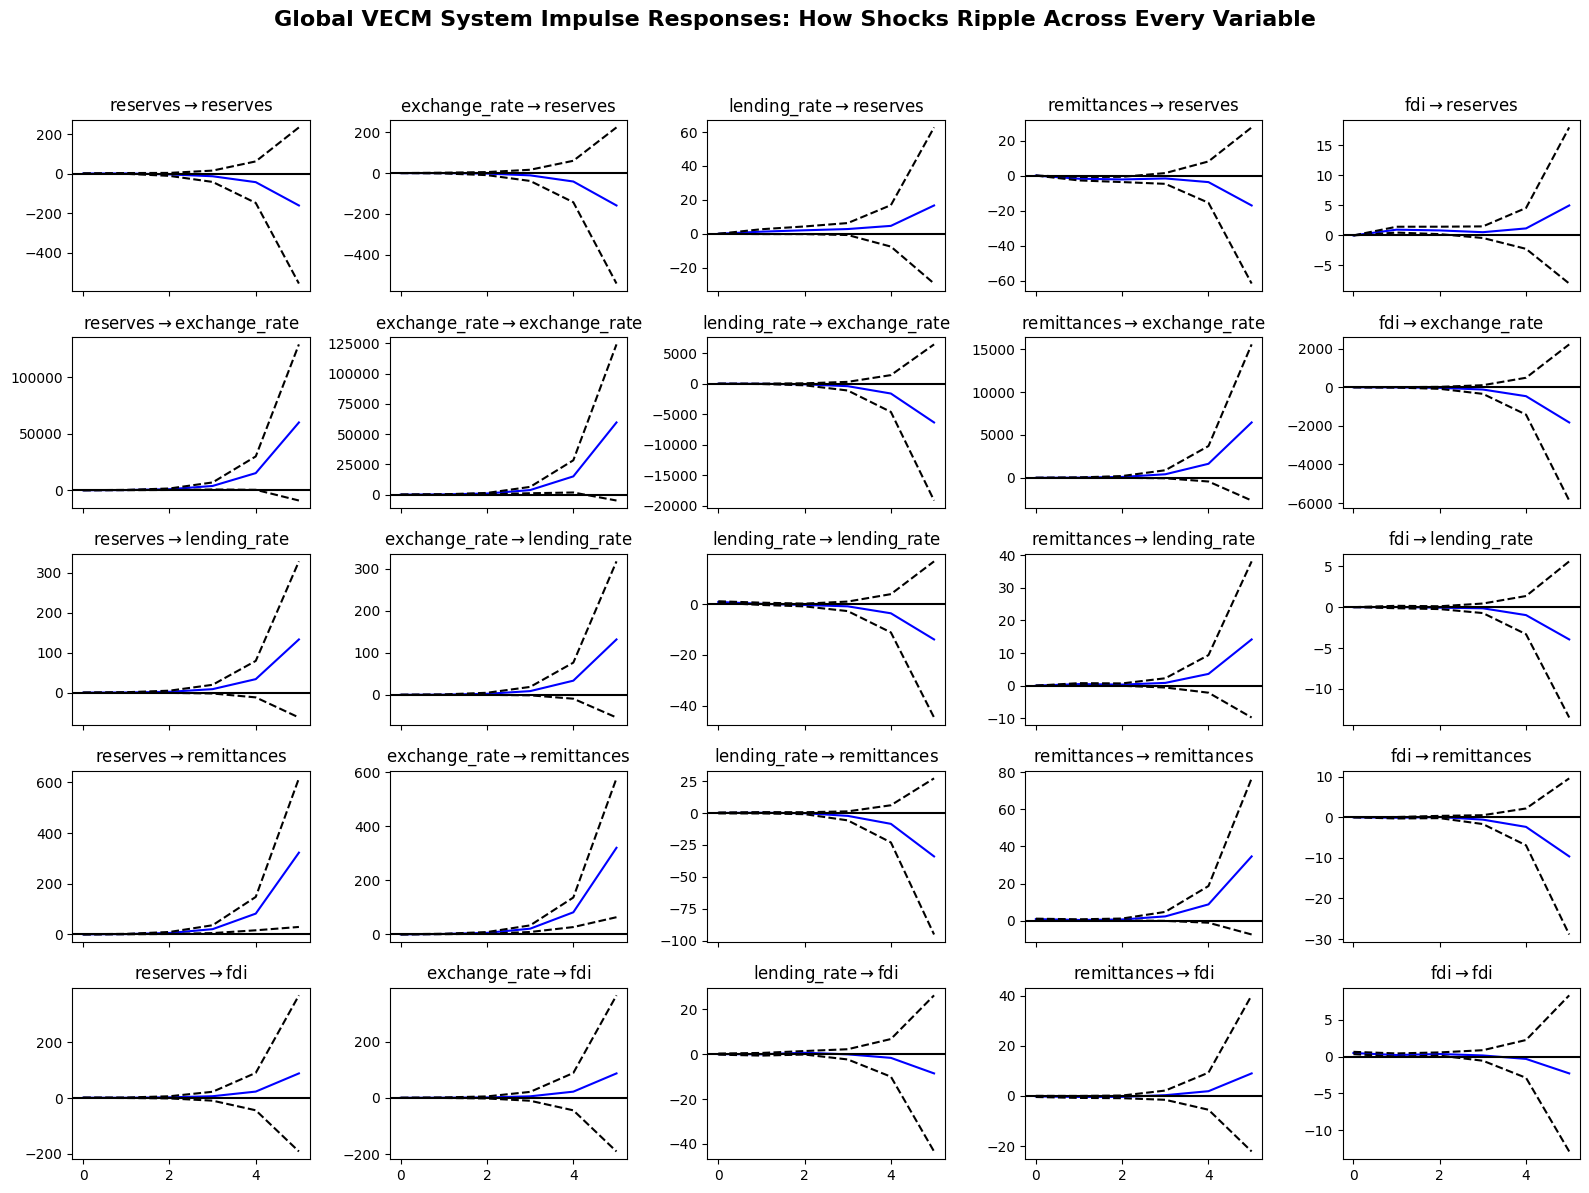

In [13]:
import matplotlib.pyplot as plt

# Generate the full system IRF data for a 5-year window
irf = vecm_results.irf(periods=5)

# Plot the entire matrix of relationships automatically
fig = irf.plot(orth=True, figsize=(16, 12))

plt.suptitle("Global VECM System Impulse Responses: How Shocks Ripple Across Every Variable",
             fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('IRF.png', bbox_inches='tight', dpi=300)
files.download('IRF.png')

plt.show()


**Forecast Error Variance Decomposition (FEVD)**

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

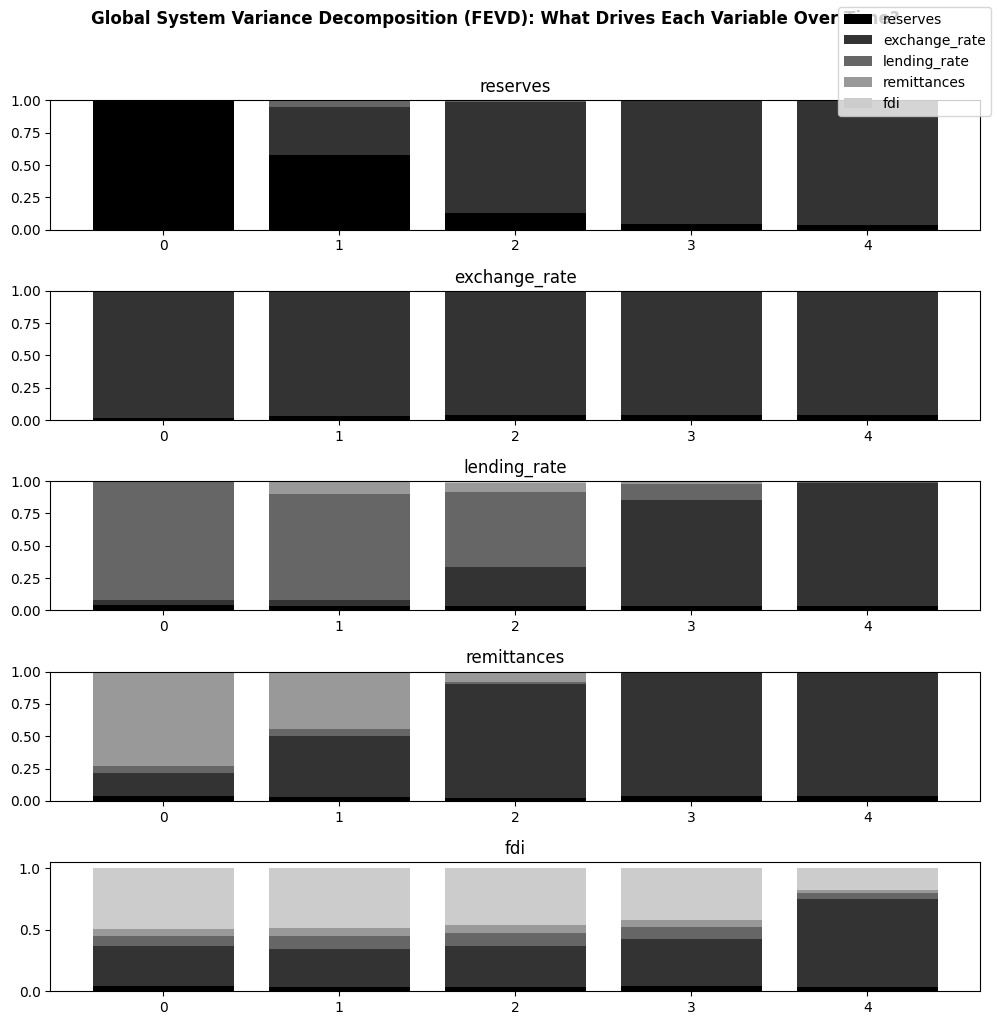

NUMERICAL VARIANCE DECOMPOSITION SUMMARY (5-YEAR HORIZON)

Drivers of Reserves at Year 5:
 -> Contribution from Reserves: 3.73%
 -> Contribution from Exchange Rate: 95.74%
 -> Contribution from Lending Rate: 0.02%
 -> Contribution from Remittances: 0.50%
 -> Contribution from Fdi: 0.01%

Drivers of Exchange Rate at Year 5:
 -> Contribution from Reserves: 3.65%
 -> Contribution from Exchange Rate: 95.83%
 -> Contribution from Lending Rate: 0.01%
 -> Contribution from Remittances: 0.51%
 -> Contribution from Fdi: 0.01%

Drivers of Lending Rate at Year 5:
 -> Contribution from Reserves: 3.61%
 -> Contribution from Exchange Rate: 94.57%
 -> Contribution from Lending Rate: 1.15%
 -> Contribution from Remittances: 0.62%
 -> Contribution from Fdi: 0.04%

Drivers of Remittances at Year 5:
 -> Contribution from Reserves: 3.62%
 -> Contribution from Exchange Rate: 95.79%
 -> Contribution from Lending Rate: 0.02%
 -> Contribution from Remittances: 0.56%
 -> Contribution from Fdi: 0.01%

Drivers o

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.vector_ar.var_model import VAR


# We use the stationary differenced data to calculate the variance splits safely
var_decomp_model = VAR(data_differenced)

# Fit the model with 1 lag to match the short-run dynamics of your VECM
var_decomp_results = var_decomp_model.fit(maxlags=1)

# Calculate the FEVD
# This tracks the variance contributions across a 5-year timeline
fevd = var_decomp_results.fevd(periods=5)

# Plot the Stacked Bar Charts
fig = fevd.plot()
plt.suptitle("Global System Variance Decomposition (FEVD): What Drives Each Variable Over Time?",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('FEVD.png', bbox_inches='tight', dpi=300)
files.download('FEVD.png')

plt.show()

print("=" * 80)
print("NUMERICAL VARIANCE DECOMPOSITION SUMMARY (5-YEAR HORIZON)")
print("=" * 80)

var_names = list(data_differenced.columns)

for target_var in var_names:
    clean_target = target_var.replace('_',' ').title()
    print(f"\nDrivers of {clean_target} at Year 5:")
    target_idx = var_names.index(target_var)

    # fevd.decomp holds the arrays: [variable_index][period_index][driver_index]
    # Index 4 represents the 5th forecast period (Year 5)
    for driver_idx, driver_name in enumerate(var_names):
        clean_driver = driver_name.replace('_',' ').title()
        percentage = fevd.decomp[target_idx][4][driver_idx] * 100
        print(f" -> Contribution from {clean_driver}: {percentage:.2f}%")

print("=" * 80)